### identify the env

two dataset strategy:

a. data from all nodes -> into a dataset and split to train 0.75/test 0.25

b. data from 
- 3 node (0, 1, 3) -> for train 
- 1 node -> test (2)


100/500/1000 seq length as frame

model: ResNet

overlapping: 40/50

report:

model.summary() 

hyper parameter (overlapping / learning rate = 0.001)

In [1]:
import pandas as pd
import numpy as np

# parameters
WINDOW_SIZE = [100, 500, 1000] # 100/500/1000
STRIDE = [40, 50] # 40/50

env_files = [
    "env/e0-bridge.csv",
    "env/e1-lake.csv",
    "env/e2-forest.csv",
    "env/e3-river.csv",
    "env/e4-garden.csv"
]

device_to_label = {
    "RIOT-BLE-0": 0,
    "RIOT-BLE-1": 1,
    "RIOT-BLE-2": 2,
    "RIOT-BLE-3": 3
}

node_files = [
    "node/node0.csv",
    "node/node1.csv",
    "node/node2.csv",
    "node/node3.csv"
]

env_to_label = {
    "env/e0-bridge.csv": 0,
    "env/e1-lake.csv": 1,
    "env/e2-forest.csv": 2,
    "env/e3-river.csv": 3,
    "env/e4-garden.csv": 4
}

In [2]:
# === create node csvs ===
from pathlib import Path

all_df = []

for file in env_files:
    df = pd.read_csv(file)  

    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = df.dropna(subset=["ts"]).copy()
    df["source_file"] = file

    all_df.append(df) # collect all dataframes for later use

df_all = pd.concat(all_df, ignore_index=True) # combine all dataframes into one

Path("node").mkdir(exist_ok=True)
for device, node_name in device_to_label.items():
    sub = df_all[df_all["device"] == device].copy() # filter by device
    sub = sub.sort_values("ts")
    sub.to_csv(f"node/node{node_name}.csv", index=False) # save to node csv
    
    print(f"node{node_name}.csv:  {len(sub)} rows")

node0.csv:  98602 rows
node1.csv:  82109 rows
node2.csv:  77771 rows
node3.csv:  82140 rows


In [3]:
def build_dataset(WINDOW_SIZE, STRIDE, node_files, env_to_label):
    # === store data ===
    X = []
    y = []
    node_ids = []

    # process each node file
    for node_id, file in enumerate(node_files):
        df = pd.read_csv(file)

        df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
        df = df.dropna(subset=["ts"]).sort_values("ts")

        for env_name, env_label in env_to_label.items():
            df_env = df[df["source_file"] == env_name].copy()

            if len(df_env) < WINDOW_SIZE:
                continue

            df_env["rssi_diff"] = df_env["rssi"].diff()

            df_env = df_env.dropna(subset=["rssi_diff"])

            y_min = df_env["rssi_diff"].min()
            y_max = df_env["rssi_diff"].max()

            if y_max - y_min == 0:
                continue

            df_env["rssi_norm"] = (df_env["rssi_diff"] - y_min) / (y_max - y_min)

            data = df_env["rssi_norm"].values

            for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
                seq = data[i:i+WINDOW_SIZE]
                X.append(seq)
                y.append(env_label)
                node_ids.append(node_id)

    X = np.array(X)
    y = np.array(y)
    node_ids = np.array(node_ids)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("node_ids shape:", node_ids.shape)

    X = X.astype(np.float32)
    y = y.astype(np.int64)
    node_ids = node_ids.astype(np.int64)

    # PyTorch Conv1d input: (batch, channels, length)
    X_data = X[:, np.newaxis, :]  
    print("X_data shape:", X_data.shape)
    return X_data, y, node_ids

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# =========================
# Version 1: random split
# =========================

def random_split(X_data, y):
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_data, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # turn into PyTorch tensors
    X_train_r_tensor = torch.tensor(X_train_r, dtype=torch.float32)
    X_test_r_tensor  = torch.tensor(X_test_r, dtype=torch.float32)
    y_train_r_tensor = torch.tensor(y_train_r, dtype=torch.long)
    y_test_r_tensor  = torch.tensor(y_test_r, dtype=torch.long)

    # create Dataset and DataLoader
    train_dataset_r = TensorDataset(X_train_r_tensor, y_train_r_tensor)
    test_dataset_r  = TensorDataset(X_test_r_tensor, y_test_r_tensor)

    train_loader_r = DataLoader(train_dataset_r, batch_size=64, shuffle=True)
    test_loader_r  = DataLoader(test_dataset_r, batch_size=64, shuffle=False)

    print("X_train:", X_train_r_tensor.shape)
    print("X_test :", X_test_r_tensor.shape)
    print("y_train:", y_train_r_tensor.shape)
    print("y_test :", y_test_r_tensor.shape)
    print("\n")
    return train_loader_r, test_loader_r, X_test_r_tensor, y_test_r

In [5]:
# =========================
# Version 2: node-based split
# =========================

def node_based_split(X_data, y, node_ids):
    train_nodes = [0, 1, 3]   
    test_node = 2             

    train_mask = np.isin(node_ids, train_nodes)
    test_mask = (node_ids == test_node)

    X_train_n = X_data[train_mask]
    y_train_n = y[train_mask]

    X_test_n = X_data[test_mask]
    y_test_n = y[test_mask]

    # turn into PyTorch tensors
    X_train_n_tensor = torch.tensor(X_train_n, dtype=torch.float32)
    X_test_n_tensor  = torch.tensor(X_test_n, dtype=torch.float32)
    y_train_n_tensor = torch.tensor(y_train_n, dtype=torch.long)
    y_test_n_tensor  = torch.tensor(y_test_n, dtype=torch.long)

    print("X_train_n_tensor shape:", X_train_n_tensor.shape)
    print("y_train_n_tensor shape:", y_train_n_tensor.shape)

    # create Dataset and DataLoader
    train_dataset_n = TensorDataset(X_train_n_tensor, y_train_n_tensor)
    test_dataset_n  = TensorDataset(X_test_n_tensor, y_test_n_tensor)

    train_loader_n = DataLoader(train_dataset_n, batch_size=64, shuffle=True)
    test_loader_n  = DataLoader(test_dataset_n, batch_size=64, shuffle=False)

    print("\n=== Version 2: Env-based Split ===")
    print("Train nodes:", train_nodes)
    print("Test node :", test_node)
    print("X_train:", X_train_n_tensor.shape)
    print("X_test :", X_test_n_tensor.shape)
    print("y_train:", y_train_n_tensor.shape)
    print("y_test :", y_test_n_tensor.shape)
    return train_loader_n, test_loader_n, X_test_n_tensor, y_test_n

In [6]:
# === Residual Block ===
import torch.nn as nn

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels) # batch norm after conv1
        self.relu = nn.ReLU(inplace=True)

        # self.dropout = nn.Dropout(p=0.1) # dropout layer

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels) # batch norm after conv2

        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels: # projection shortcut if dimensions differ
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    # forward pass
    def forward(self, x):
        identity = self.shortcut(x)

        # conv1 -> bn -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # out = self.dropout(out) # dropout 

        # conv2 -> bn
        out = self.conv2(out)
        out = self.bn2(out)

        # add shortcut
        out += identity
        out = self.relu(out)

        return out

In [7]:
# === ResNet1D Model ===

class ResNet1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # initial convolution and pooling
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # layer1
        self.layer1 = nn.Sequential(
            ResidualBlock1D(16, 16, stride=1)
        )

        # layer2
        self.layer2 = nn.Sequential(
            ResidualBlock1D(16, 32, stride=2)
        )

        # layer3
        self.layer3 = nn.Sequential(
            ResidualBlock1D(32, 64, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        # self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)         # (B, 1, 100) -> (B, 16, 25)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)  # (B, 64, 1)
        x = x.squeeze(-1)        # (B, 64, 1) -> (B, 64)
        # x = self.dropout(x)      # dropout
        x = self.fc(x)           # (B, num_classes)
        return x

# num_classes = len(np.unique(y))
model = ResNet1D(num_classes=5) # 5 classes for 5 environments
print(model)

ResNet1D(
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=T

In [8]:
# === Model Summary ===

from torchinfo import summary

summary(
    model,
    input_size=(64, 1, 500)  # (batch, channel, length)
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet1D                                 [64, 5]                   --
├─Sequential: 1-1                        [64, 16, 125]             --
│    └─Conv1d: 2-1                       [64, 16, 250]             112
│    └─BatchNorm1d: 2-2                  [64, 16, 250]             32
│    └─ReLU: 2-3                         [64, 16, 250]             --
│    └─MaxPool1d: 2-4                    [64, 16, 125]             --
├─Sequential: 1-2                        [64, 16, 125]             --
│    └─ResidualBlock1D: 2-5              [64, 16, 125]             --
│    │    └─Sequential: 3-1              [64, 16, 125]             --
│    │    └─Conv1d: 3-2                  [64, 16, 125]             768
│    │    └─BatchNorm1d: 3-3             [64, 16, 125]             32
│    │    └─ReLU: 3-4                    [64, 16, 125]             --
│    │    └─Conv1d: 3-5                  [64, 16, 125]             768
│    │    └─

In [9]:
# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
# =========================
# Step 4: training loop
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total

In [11]:
# === Draw Plot ===

import matplotlib.pyplot as plt

def draw_plot(train_losses, test_losses, train_accs, test_accs):
    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(test_accs, label="Test Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    
    plt.show()

In [12]:
# =========================
# Step 5: run training
# =========================
num_epochs = 20


def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, device, num_epochs):
      # best_test_loss = float("inf")
      # best_state = None

      train_losses = []
      test_losses = []
      train_accs = []
      test_accs = []

      for epoch in range(num_epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            test_loss, test_acc = evaluate(model, test_loader, criterion, device)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
            
      draw_plot(train_losses, test_losses, train_accs, test_accs)

      # # save best model
      # if test_loss < best_test_loss:
      #     best_test_loss = test_loss
      #     best_state = model.state_dict()
      # model.load_state_dict(best_state)

In [13]:
# =========================
# Step 6: prediction example
# =========================

def predict(model, X_test_tensor, y_test, device):
    model.eval()

    with torch.no_grad():
        sample_x = X_test_tensor[:5].to(device)
        outputs = model(sample_x)
        preds = outputs.argmax(dim=1).cpu().numpy()

    print("Pred:", preds)
    print("True:", y_test[:5])

In [14]:
# =========================
# Step 7: confusion matrix
# =========================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def compute_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    cm = confusion_matrix(all_true, all_preds)
    acc = accuracy_score(all_true, all_preds)

    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(all_true, all_preds))
    print(f"\nAccuracy: {acc:.4f}\n")

    return f"{acc:.4f}"


=== Version 1: random split ===


--- WINDOW_SIZE=100, STRIDE=40 ---

X shape: (8477, 100)
y shape: (8477,)
node_ids shape: (8477,)
X_data shape: (8477, 1, 100)
X_train: torch.Size([6357, 1, 100])
X_test : torch.Size([2120, 1, 100])
y_train: torch.Size([6357])
y_test : torch.Size([2120])


Epoch [1/20] Train Loss: 1.1254, Train Acc: 0.5377 | Test Loss: 0.9412, Test Acc: 0.6104
Epoch [2/20] Train Loss: 0.8155, Train Acc: 0.6667 | Test Loss: 0.6528, Test Acc: 0.7505
Epoch [3/20] Train Loss: 0.7080, Train Acc: 0.7041 | Test Loss: 0.5893, Test Acc: 0.7571
Epoch [4/20] Train Loss: 0.6824, Train Acc: 0.7151 | Test Loss: 0.5263, Test Acc: 0.8108
Epoch [5/20] Train Loss: 0.6242, Train Acc: 0.7426 | Test Loss: 0.5138, Test Acc: 0.7948
Epoch [6/20] Train Loss: 0.6223, Train Acc: 0.7433 | Test Loss: 0.4754, Test Acc: 0.8264
Epoch [7/20] Train Loss: 0.6099, Train Acc: 0.7461 | Test Loss: 0.4583, Test Acc: 0.8392
Epoch [8/20] Train Loss: 0.6000, Train Acc: 0.7562 | Test Loss: 0.5285, Test Acc: 0.7

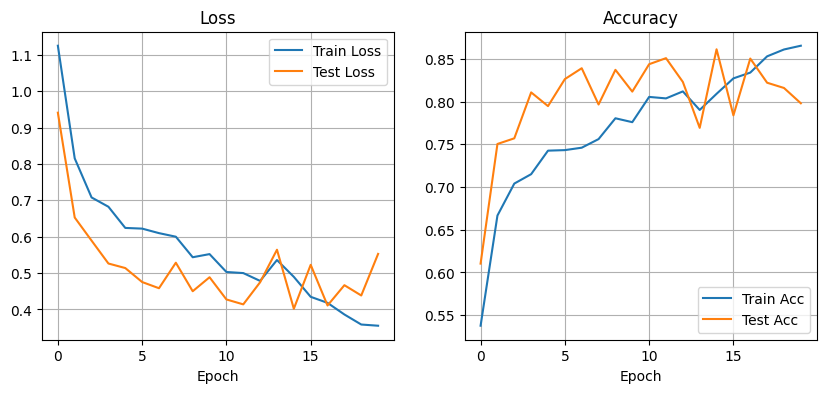

Pred: [3 0 0 4 2]
True: [1 0 0 4 3]
Confusion Matrix:
 [[463  27   6   1   0]
 [  0 185  74  20   1]
 [  0  24 400  45  11]
 [  4  19 111 319  16]
 [  3   1  64   1 325]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       497
           1       0.72      0.66      0.69       280
           2       0.61      0.83      0.70       480
           3       0.83      0.68      0.75       469
           4       0.92      0.82      0.87       394

    accuracy                           0.80      2120
   macro avg       0.81      0.79      0.79      2120
weighted avg       0.82      0.80      0.80      2120


Accuracy: 0.7981





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (6779, 100)
y shape: (6779,)
node_ids shape: (6779,)
X_data shape: (6779, 1, 100)
X_train: torch.Size([5084, 1, 100])
X_test : torch.Size([1695, 1, 100])
y_train: torch.Size([5084])
y_test : torch.Size([1695])


Epoch [1/20] Train Loss: 0.4843, Tr

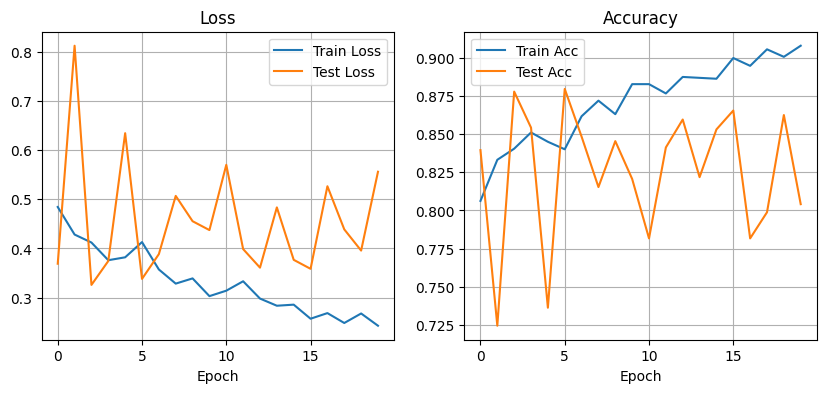

Pred: [4 4 3 2 4]
True: [4 4 3 2 4]
Confusion Matrix:
 [[395   0   1   0   1]
 [ 34 160  16  12   2]
 [  1  28 198  26 131]
 [  6  25  25 313   6]
 [  0   5   6   7 297]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       397
           1       0.73      0.71      0.72       224
           2       0.80      0.52      0.63       384
           3       0.87      0.83      0.85       375
           4       0.68      0.94      0.79       315

    accuracy                           0.80      1695
   macro avg       0.80      0.80      0.79      1695
weighted avg       0.81      0.80      0.80      1695


Accuracy: 0.8041





--- WINDOW_SIZE=500, STRIDE=40 ---

X shape: (8277, 500)
y shape: (8277,)
node_ids shape: (8277,)
X_data shape: (8277, 1, 500)
X_train: torch.Size([6207, 1, 500])
X_test : torch.Size([2070, 1, 500])
y_train: torch.Size([6207])
y_test : torch.Size([2070])


Epoch [1/20] Train Loss: 0.1956, Tr

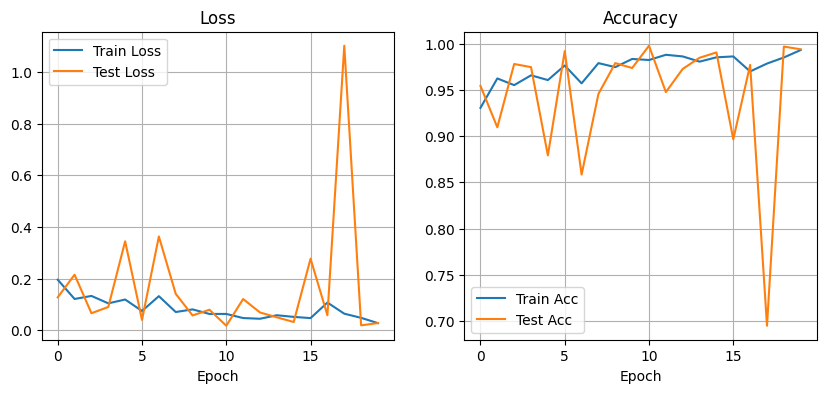

Pred: [2 3 1 0 3]
True: [2 3 1 0 3]
Confusion Matrix:
 [[487   0   0   0   0]
 [  0 270   0   0   0]
 [  0   1 464   5   0]
 [  0   6   0 453   0]
 [  0   0   0   0 384]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       487
           1       0.97      1.00      0.99       270
           2       1.00      0.99      0.99       470
           3       0.99      0.99      0.99       459
           4       1.00      1.00      1.00       384

    accuracy                           0.99      2070
   macro avg       0.99      0.99      0.99      2070
weighted avg       0.99      0.99      0.99      2070


Accuracy: 0.9942





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (6619, 500)
y shape: (6619,)
node_ids shape: (6619,)
X_data shape: (6619, 1, 500)
X_train: torch.Size([4964, 1, 500])
X_test : torch.Size([1655, 1, 500])
y_train: torch.Size([4964])
y_test : torch.Size([1655])


Epoch [1/20] Train Loss: 0.1604, Tr

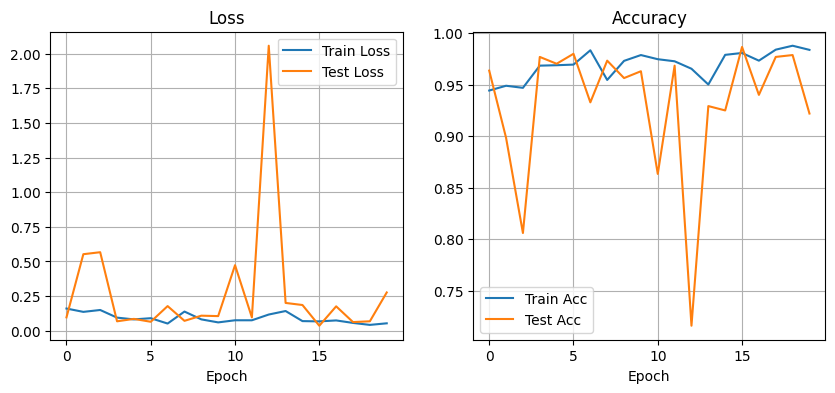

Pred: [3 2 2 2 4]
True: [3 2 2 2 4]
Confusion Matrix:
 [[387   2   0   0   0]
 [  0 147  45  21   3]
 [  4   0 365   1   6]
 [  0   0  10 323  34]
 [  0   0   3   0 304]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       389
           1       0.99      0.68      0.81       216
           2       0.86      0.97      0.91       376
           3       0.94      0.88      0.91       367
           4       0.88      0.99      0.93       307

    accuracy                           0.92      1655
   macro avg       0.93      0.90      0.91      1655
weighted avg       0.93      0.92      0.92      1655


Accuracy: 0.9221





--- WINDOW_SIZE=1000, STRIDE=40 ---

X shape: (8023, 1000)
y shape: (8023,)
node_ids shape: (8023,)
X_data shape: (8023, 1, 1000)
X_train: torch.Size([6017, 1, 1000])
X_test : torch.Size([2006, 1, 1000])
y_train: torch.Size([6017])
y_test : torch.Size([2006])


Epoch [1/20] Train Loss: 0.026

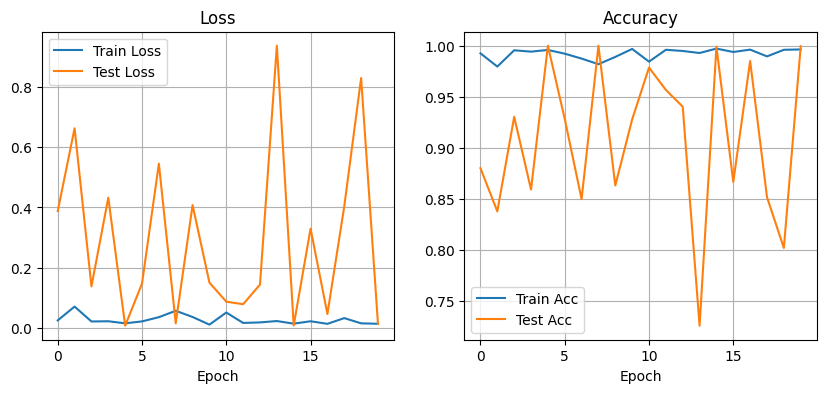

Pred: [1 3 3 1 2]
True: [1 3 3 1 2]
Confusion Matrix:
 [[474   0   0   0   0]
 [  0 257   0   0   0]
 [  0   0 456   1   0]
 [  0   0   0 446   0]
 [  0   0   0   0 372]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       474
           1       1.00      1.00      1.00       257
           2       1.00      1.00      1.00       457
           3       1.00      1.00      1.00       446
           4       1.00      1.00      1.00       372

    accuracy                           1.00      2006
   macro avg       1.00      1.00      1.00      2006
weighted avg       1.00      1.00      1.00      2006


Accuracy: 0.9995





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (6419, 1000)
y shape: (6419,)
node_ids shape: (6419,)
X_data shape: (6419, 1, 1000)
X_train: torch.Size([4814, 1, 1000])
X_test : torch.Size([1605, 1, 1000])
y_train: torch.Size([4814])
y_test : torch.Size([1605])


Epoch [1/20] Train Loss: 0.075

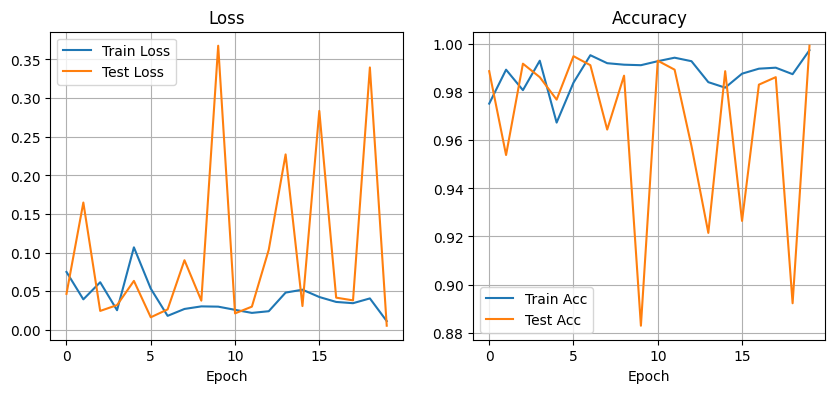

Pred: [1 0 0 2 1]
True: [1 0 0 2 1]
Confusion Matrix:
 [[379   0   0   0   0]
 [  0 206   0   0   0]
 [  0   1 365   0   0]
 [  0   0   0 357   0]
 [  0   0   0   0 297]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       379
           1       1.00      1.00      1.00       206
           2       1.00      1.00      1.00       366
           3       1.00      1.00      1.00       357
           4       1.00      1.00      1.00       297

    accuracy                           1.00      1605
   macro avg       1.00      1.00      1.00      1605
weighted avg       1.00      1.00      1.00      1605


Accuracy: 0.9994






In [15]:
# ===========================
# version 1: random split
# ===========================

results_random = []

print("\n=== Version 1: random split ===\n")

for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, node_files=node_files, env_to_label=env_to_label)

            train_loader_r, test_loader_r, X_test_r_tensor, y_test_r = random_split(X_data, y)

            train_and_evaluate(model, train_loader_r, test_loader_r, criterion, optimizer, device, num_epochs)

            predict(model, X_test_r_tensor, y_test_r, device)
            
            acc = compute_confusion_matrix(model, test_loader_r, device)
            
            results_random.append({
            "window": window_size,
            "stride": stride,
            "acc": acc
            })

            print("\n\n")


=== Version 2: node-based split ===


--- WINDOW_SIZE=100, STRIDE=40 ---

X shape: (8477, 100)
y shape: (8477,)
node_ids shape: (8477,)
X_data shape: (8477, 1, 100)
X_train_n_tensor shape: torch.Size([6543, 1, 100])
y_train_n_tensor shape: torch.Size([6543])

=== Version 2: Env-based Split ===
Train nodes: [0, 1, 3]
Test node : 2
X_train: torch.Size([6543, 1, 100])
X_test : torch.Size([1934, 1, 100])
y_train: torch.Size([6543])
y_test : torch.Size([1934])
Epoch [1/20] Train Loss: 0.4631, Train Acc: 0.8502 | Test Loss: 1.8440, Test Acc: 0.6065
Epoch [2/20] Train Loss: 0.2564, Train Acc: 0.8979 | Test Loss: 0.9963, Test Acc: 0.6794
Epoch [3/20] Train Loss: 0.2129, Train Acc: 0.9214 | Test Loss: 1.0653, Test Acc: 0.6386
Epoch [4/20] Train Loss: 0.1842, Train Acc: 0.9295 | Test Loss: 1.8853, Test Acc: 0.5620
Epoch [5/20] Train Loss: 0.1615, Train Acc: 0.9381 | Test Loss: 1.9371, Test Acc: 0.4343
Epoch [6/20] Train Loss: 0.1732, Train Acc: 0.9386 | Test Loss: 1.3381, Test Acc: 0.6003
Epoch

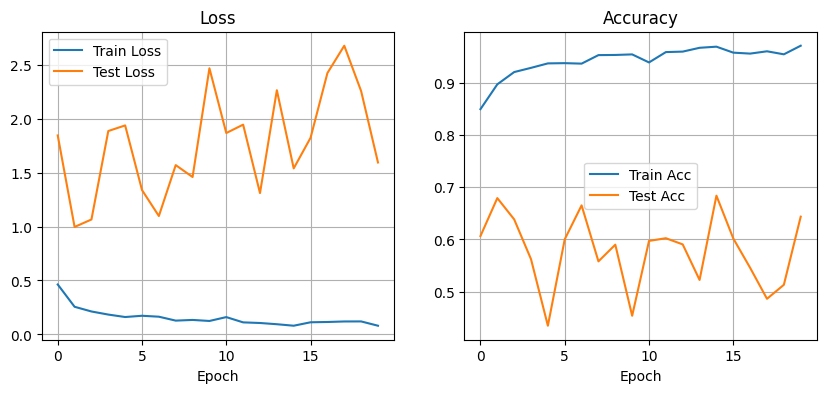

Pred: [3 3 0 0 3]
True: [0 0 0 0 0]
Confusion Matrix:
 [[ 78   0  18 193   0]
 [  0 180   0  15   0]
 [  0   3 566   0  37]
 [  0 259 164  53   0]
 [  0   0   0   0 368]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.27      0.43       289
           1       0.41      0.92      0.57       195
           2       0.76      0.93      0.84       606
           3       0.20      0.11      0.14       476
           4       0.91      1.00      0.95       368

    accuracy                           0.64      1934
   macro avg       0.66      0.65      0.58      1934
weighted avg       0.65      0.64      0.60      1934


Accuracy: 0.6437





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (6779, 100)
y shape: (6779,)
node_ids shape: (6779,)
X_data shape: (6779, 1, 100)
X_train_n_tensor shape: torch.Size([5232, 1, 100])
y_train_n_tensor shape: torch.Size([5232])

=== Version 2: Env-based Split ===
Train nodes: [0, 1, 3]
Test node : 

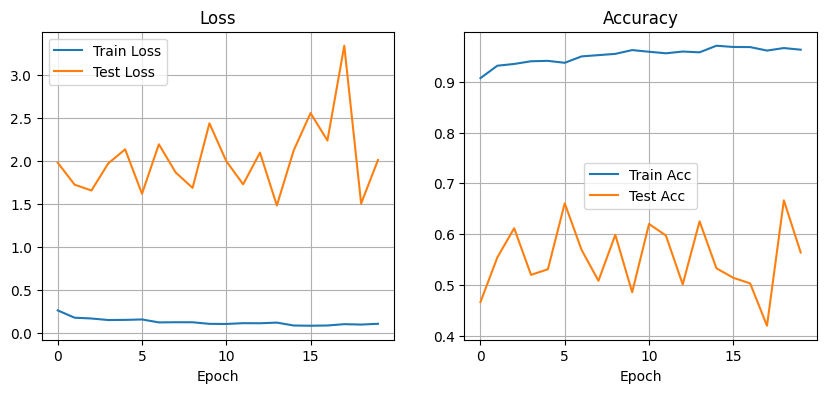

Pred: [3 0 0 3 3]
True: [0 0 0 0 0]
Confusion Matrix:
 [[ 36   0   3 192   0]
 [  0 120   0  36   0]
 [  0   3 419   0  63]
 [  0 226  83   3  69]
 [  0   0   0   0 294]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.16      0.27       231
           1       0.34      0.77      0.48       156
           2       0.83      0.86      0.85       485
           3       0.01      0.01      0.01       381
           4       0.69      1.00      0.82       294

    accuracy                           0.56      1547
   macro avg       0.58      0.56      0.48      1547
weighted avg       0.58      0.56      0.51      1547


Accuracy: 0.5637





--- WINDOW_SIZE=500, STRIDE=40 ---

X shape: (8277, 500)
y shape: (8277,)
node_ids shape: (8277,)
X_data shape: (8277, 1, 500)
X_train_n_tensor shape: torch.Size([6393, 1, 500])
y_train_n_tensor shape: torch.Size([6393])

=== Version 2: Env-based Split ===
Train nodes: [0, 1, 3]
Test node : 

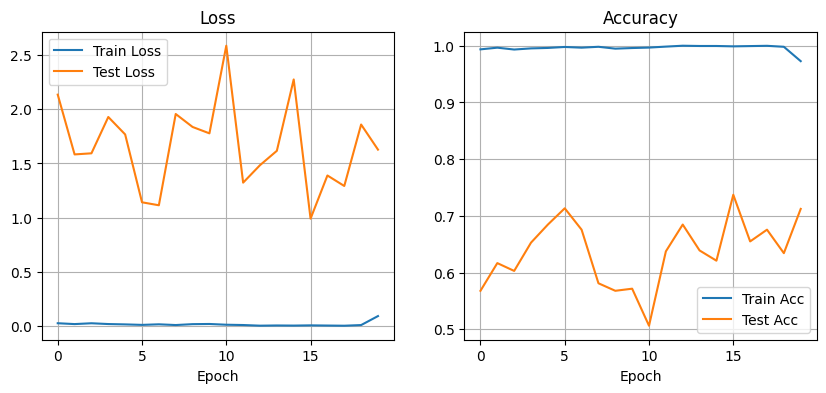

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[189   0   0  90   0]
 [  0 184   0   1   0]
 [  0   0 596   0   0]
 [  0 107 304  15  40]
 [  0   0   0   0 358]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.68      0.81       279
           1       0.63      0.99      0.77       185
           2       0.66      1.00      0.80       596
           3       0.14      0.03      0.05       466
           4       0.90      1.00      0.95       358

    accuracy                           0.71      1884
   macro avg       0.67      0.74      0.68      1884
weighted avg       0.63      0.71      0.64      1884


Accuracy: 0.7123





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (6619, 500)
y shape: (6619,)
node_ids shape: (6619,)
X_data shape: (6619, 1, 500)
X_train_n_tensor shape: torch.Size([5112, 1, 500])
y_train_n_tensor shape: torch.Size([5112])

=== Version 2: Env-based Split ===
Train nodes: [0, 1, 3]
Test node : 

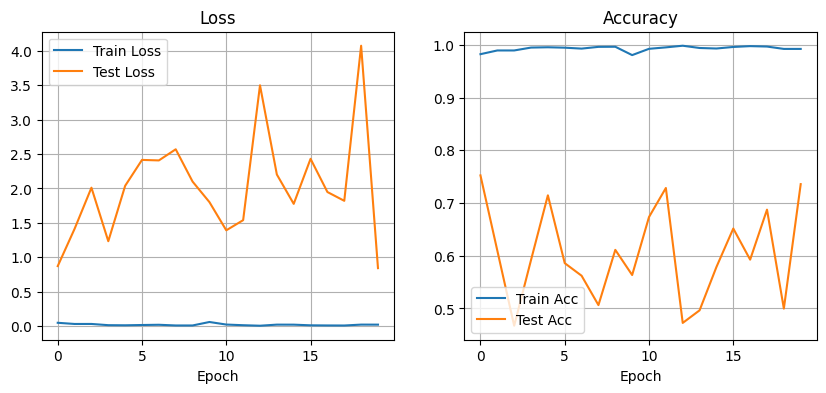

Pred: [3 0 0 2 3]
True: [0 0 0 0 0]
Confusion Matrix:
 [[219   0   1   3   0]
 [  0 127   0  21   0]
 [  0   0 467   2   8]
 [  0  20   7  10 336]
 [  0   0   0   0 286]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       223
           1       0.86      0.86      0.86       148
           2       0.98      0.98      0.98       477
           3       0.28      0.03      0.05       373
           4       0.45      1.00      0.62       286

    accuracy                           0.74      1507
   macro avg       0.72      0.77      0.70      1507
weighted avg       0.70      0.74      0.67      1507


Accuracy: 0.7359





--- WINDOW_SIZE=1000, STRIDE=40 ---

X shape: (8023, 1000)
y shape: (8023,)
node_ids shape: (8023,)
X_data shape: (8023, 1, 1000)
X_train_n_tensor shape: torch.Size([6202, 1, 1000])
y_train_n_tensor shape: torch.Size([6202])

=== Version 2: Env-based Split ===
Train nodes: [0, 1, 3]
Test nod

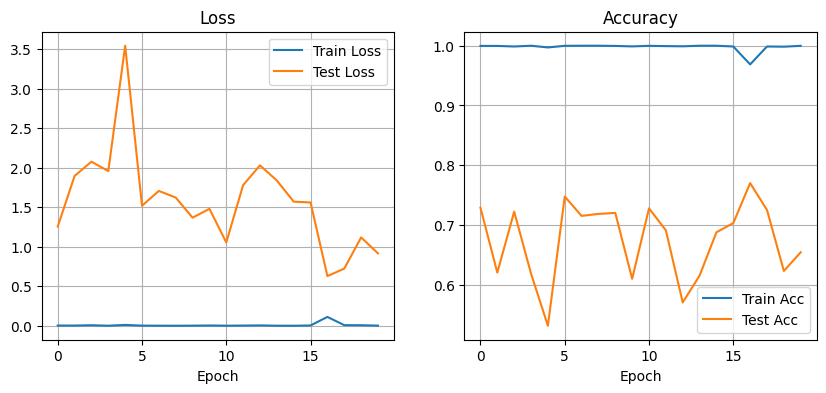

Pred: [3 3 3 3 3]
True: [0 0 0 0 0]
Confusion Matrix:
 [[ 62   0   0 204   0]
 [  0 141   0  32   0]
 [  0   0 550   0  33]
 [  0  40 267  93  54]
 [  0   0   0   0 345]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.23      0.38       266
           1       0.78      0.82      0.80       173
           2       0.67      0.94      0.79       583
           3       0.28      0.20      0.24       454
           4       0.80      1.00      0.89       345

    accuracy                           0.65      1821
   macro avg       0.71      0.64      0.62      1821
weighted avg       0.66      0.65      0.61      1821


Accuracy: 0.6540





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (6419, 1000)
y shape: (6419,)
node_ids shape: (6419,)
X_data shape: (6419, 1, 1000)
X_train_n_tensor shape: torch.Size([4962, 1, 1000])
y_train_n_tensor shape: torch.Size([4962])

=== Version 2: Env-based Split ===
Train nodes: [0, 1, 3]
Test nod

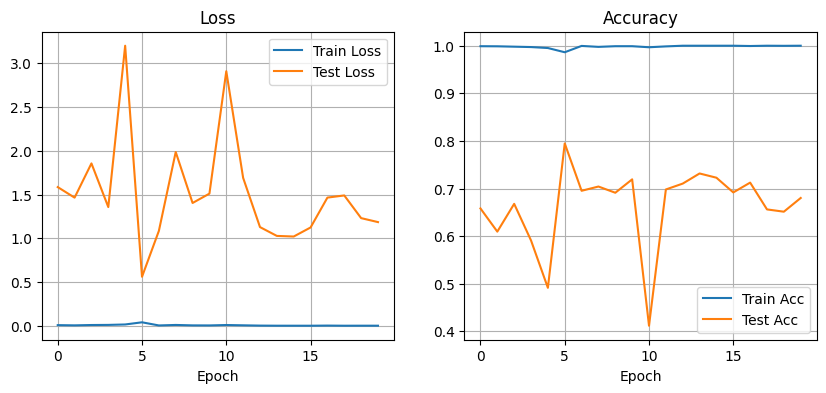

Pred: [3 0 0 0 3]
True: [0 0 0 0 0]
Confusion Matrix:
 [[129   0   0  84   0]
 [  0 130   0   8   0]
 [  0   0 419   0  48]
 [  0  60 151  37 115]
 [  0   0   0   0 276]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.61      0.75       213
           1       0.68      0.94      0.79       138
           2       0.74      0.90      0.81       467
           3       0.29      0.10      0.15       363
           4       0.63      1.00      0.77       276

    accuracy                           0.68      1457
   macro avg       0.67      0.71      0.66      1457
weighted avg       0.64      0.68      0.63      1457


Accuracy: 0.6802






In [16]:
# ===========================
# version 2: node-based split
# ===========================

results_node = []

print("\n=== Version 2: node-based split ===\n")
for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, node_files=node_files, env_to_label=env_to_label)

            train_loader_n, test_loader_n, X_test_n_tensor, y_test_n = node_based_split(X_data, y, env_ids)

            train_and_evaluate(model, train_loader_n, test_loader_n, criterion, optimizer, device, num_epochs)

            predict(model, X_test_n_tensor, y_test_n, device)

            acc = compute_confusion_matrix(model, test_loader_n, device)

            results_node.append({
            "window": window_size,
            "stride": stride,
            "acc": acc
            })
            print("\n\n")

In [17]:
df_results_ran = pd.DataFrame(results_random)
print("\n=== Random Split Accuracy Results ===\n")
print(f"{df_results_ran.to_string(index=False)}\n")

df_results_node = pd.DataFrame(results_node)
print("\n=== Node-based Split Accuracy Results ===\n")
print(f"{df_results_node.to_string(index=False)}\n")


=== Random Split Accuracy Results ===

 window  stride    acc
    100      40 0.7981
    100      50 0.8041
    500      40 0.9942
    500      50 0.9221
   1000      40 0.9995
   1000      50 0.9994


=== Node-based Split Accuracy Results ===

 window  stride    acc
    100      40 0.6437
    100      50 0.5637
    500      40 0.7123
    500      50 0.7359
   1000      40 0.6540
   1000      50 0.6802

